In [1]:
pip install pybloom_live

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pybloom_live: filename=pybloom_live-4.0.0-py3-none-any.whl size=9320 sha256=3e3c1b908915b2f6420cdd22e78ecc061420e32cf5ddf48f5ceb454272127acf
  Stored in directory: /teamspace/studios/this_studio/.cache/pip/wheels/1d/5e/b8/19c04c108b0acd2ca53b85fcc09eeed323ecdfea0e36bd134e
Successfully built pybloom_live
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pybloom_live]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests

url = "https://ember.elastic.co/ember_dataset_2018_2.tar.bz2"
filename = "ember_dataset_2018_2.tar.bz2"

response = requests.get(url, stream=True)
response.raise_for_status()

with open(filename, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        if chunk:
            f.write(chunk)

print("Download complete!")


Download complete!


In [3]:
import tarfile
with tarfile.open("ember_dataset_2018_2.tar.bz2", "r:bz2") as tar:
    tar.extractall("ember2018")

/tmp/ipykernel_4139/957078492.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("ember2018")


Extracted to ./ember2018/


In [5]:
!pip install -q lightgbm scikit-learn pybloom_live bitarray tqdm matplotlib pandas

In [1]:
# %%
import numpy as np
import pandas as pd
import math
import pickle
import time
import json
import os

import lightgbm as lgb
from pybloom_live import BloomFilter
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from pathlib import Path

EMBER_DIR = "./ember2018/ember2018/"
OUT_DIR = "./ember_full_results/"

TARGET_FPRS = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

PLBF_REGIONS = 8
STAGE1_TREES = 50
MAX_NEG_SAMPLE = 200000
SEED = 42
MAX_CLIP = 1e6

np.random.seed(SEED)

LN2 = math.log(2)
LN2_SQ = LN2 * LN2

if not os.path.exists(OUT_DIR):
    Path(OUT_DIR).mkdir(exist_ok=True)


In [2]:
# %%
def flatten_vals(x):
    out_list = []

    if isinstance(x, dict):
        for k in x:
            v = x[k]
            out_list.extend(flatten_vals(v))

    elif isinstance(x, (list, tuple, set)):
        for item in x:
            out_list.extend(flatten_vals(item))

    else:
        try:
            num = float(x)
            out_list.append(num)
        except:
            out_list.append(0.0)

    return out_list


def vectorize(d):
    vec = []

    structure = [
        ("general", 11),
        ("header", 62),
        ("section", 255),
        ("imports", 128),
        ("datadirectories", 30),
        ("bytehistogram", 256),
        ("byteentropy", 256),
        ("strings", 128),
        ("coff", 16),
        ("optionalheader", 16),
        ("datadirectory", 16),
        ("versioninfo", 81)
    ]

    for field, size in structure:
        raw = d.get(field, [])
        flat = flatten_vals(raw)

        if len(flat) < size:
            missing = size - len(flat)
            pad = [0.0] * missing
            flat = flat + pad
        else:
            flat = flat[:size]

        for v in flat:
            vec.append(v)

    arr = np.array(vec, dtype=np.float32)
    return arr


In [3]:
# %%
def load_train(folder, parts=6):
    X = []
    y = []

    for i in range(parts):
        name = f"train_features_{i}.jsonl"
        path = os.path.join(folder, name)

        if os.path.exists(path) is False:
            continue

        print("Reading:", path)

        with open(path, "r") as f:
            for line in f:
                d = json.loads(line)

                label = d.get("label", -1)
                vec = vectorize(d)

                y.append(label)
                X.append(vec)

    X = np.vstack(X)
    y = np.array(y)

    return X, y


def load_test(folder):
    X = []
    y = []

    path = os.path.join(folder, "test_features.jsonl")
    print("Reading:", path)

    with open(path, "r") as f:
        for line in f:
            d = json.loads(line)

            label = d.get("label", -1)
            vec = vectorize(d)

            y.append(label)
            X.append(vec)

    X = np.vstack(X)
    y = np.array(y)

    return X, y


print("Loading data...")

X_train, y_train = load_train(EMBER_DIR)
X_test, y_test = load_test(EMBER_DIR)

train_mask = (y_train != -1)
test_mask  = (y_test != -1)

X_train = X_train[train_mask]
y_train = y_train[train_mask]

X_test = X_test[test_mask]
y_test = y_test[test_mask]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Loading data...
Reading: ./ember2018/ember2018/train_features_0.jsonl
Reading: ./ember2018/ember2018/train_features_1.jsonl
Reading: ./ember2018/ember2018/train_features_2.jsonl


/tmp/ipykernel_4047/4141961583.py:56: RuntimeWarning: overflow encountered in cast
  arr = np.array(vec, dtype=np.float32)


Reading: ./ember2018/ember2018/train_features_3.jsonl
Reading: ./ember2018/ember2018/train_features_4.jsonl
Reading: ./ember2018/ember2018/train_features_5.jsonl
Reading: ./ember2018/ember2018/test_features.jsonl
Train shape: (600000, 1255)
Test shape: (200000, 1255)


In [4]:
# %%
print("Cleaning values...")

X_train = np.nan_to_num(X_train, nan=0.0, posinf=MAX_CLIP, neginf=-MAX_CLIP)
X_test  = np.nan_to_num(X_test,  nan=0.0, posinf=MAX_CLIP, neginf=-MAX_CLIP)

X_train = np.clip(X_train, -MAX_CLIP, MAX_CLIP)
X_test  = np.clip(X_test,  -MAX_CLIP,  MAX_CLIP)

ok_train = np.isfinite(X_train).all()
ok_test  = np.isfinite(X_test).all()

if not ok_train:
    raise ValueError("Train still has bad values")

if not ok_test:
    raise ValueError("Test still has bad values")

print("Scaling now...")

scaler = StandardScaler(with_mean=False)
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Scaling done")


Cleaning values...
Scaling now...
Scaling done


In [5]:
# %%
print("Training model...")

model = lgb.LGBMClassifier(
    objective='binary',
    num_leaves=64,
    learning_rate=0.05,
    n_estimators=200,
    n_jobs=-1,
    random_state=SEED
)

start_time = time.time()

model.fit(
    X_train,
    y_train,
    callbacks=[lgb.callback.log_evaluation(period=0)]
)

elapsed = time.time() - start_time
print("Training finished in", round(elapsed, 2), "seconds")

scores = model.predict_proba(X_test)[:, 1]

model_bytes = len(pickle.dumps(model, protocol=4))
model_bits = model_bytes * 8

print("Model size (bits):", model_bits)


Training model...
[LightGBM] [Info] Number of positive: 300000, number of negative: 300000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.936536 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 132204
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 665
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training finished in 142.7 seconds
Model size (bits): 12039728


In [6]:
# %%
def bloom_bits(n, fpr):
    if n <= 0:
        return 0

    if fpr <= 0:
        return 0

    val = -n * math.log(fpr) / LN2_SQ
    bits = int(math.ceil(val))

    return bits


def make_bloom(keys, fpr):
    count = len(keys)

    if count == 0:
        return None, 0

    bf = BloomFilter(capacity=count, error_rate=float(fpr))

    for k in keys:
        bf.add(k)

    size = bloom_bits(count, fpr)
    return bf, size


def sample_neg(labels):
    idx = np.where(labels == 0)[0]
    n = len(idx)

    if n == 0:
        return np.array([])

    take = min(n, MAX_NEG_SAMPLE)

    sampled = np.random.choice(idx, take, replace=False)
    return sampled


def compute_lbf(preds, labels, target_fpr):
    best = None

    thresholds = np.linspace(0, 1, 201)

    for thr in thresholds:
        accepted = preds >= thr

        missed = np.where((accepted == False) & (labels == 1))[0]

        bf = None
        bits = 0

        if len(missed) > 0:
            keys = [str(i) for i in missed]
            bf, bits = make_bloom(keys, target_fpr)

        negs = sample_neg(labels)

        if len(negs) == 0:
            continue

        false_pos = 0

        for j in negs:
            if accepted[j]:
                false_pos += 1
            else:
                if bf is not None and str(j) in bf:
                    false_pos += 1

        fpr_meas = false_pos / len(negs)

        if fpr_meas <= target_fpr:
            if best is None:
                best = (bits, thr, fpr_meas)
            else:
                if bits < best[0]:
                    best = (bits, thr, fpr_meas)

    if best is None:
        fallback = bloom_bits(np.sum(labels == 1), target_fpr)
        return fallback, 1.0, 1.0

    return best


In [7]:
# %%
def compute_plbf(preds, labels, target_fpr):
    region_bins = 500

    bins = np.linspace(0, 1, region_bins + 1)

    pos_hist, _ = np.histogram(preds[labels == 1], bins=bins)
    neg_hist, _ = np.histogram(preds[labels == 0], bins=bins)

    if pos_hist.sum() == 0:
        pos_hist = pos_hist + 1

    if neg_hist.sum() == 0:
        neg_hist = neg_hist + 1

    pos_hist = pos_hist / pos_hist.sum()
    neg_hist = neg_hist / neg_hist.sum()

    cum = np.cumsum(pos_hist)

    cuts = []
    for i in range(PLBF_REGIONS - 1):
        target_mass = (i + 1) / PLBF_REGIONS
        idx = int(np.searchsorted(cum, target_mass))
        cuts.append(idx)

    cuts.append(len(pos_hist) - 1)

    g_list = []
    h_list = []

    start = 0
    for c in cuts:
        g = pos_hist[start:c+1].sum()
        h = neg_hist[start:c+1].sum()

        g_list.append(g)
        h_list.append(h)

        start = c + 1

    g_arr = np.array(g_list)
    h_arr = np.array(h_list)

    local_fpr = (g_arr * target_fpr) / np.maximum(h_arr, 1e-12)
    local_fpr = np.clip(local_fpr, 1e-9, 0.5)

    bin_ids = np.digitize(preds, bins) - 1
    bin_ids = np.clip(bin_ids, 0, len(bins) - 2)

    region_map = np.zeros(len(bins) - 1, dtype=int)

    s = 0
    for r, c in enumerate(cuts):
        region_map[s:c+1] = r
        s = c + 1

    counts = []

    for r in range(len(cuts)):
        c = np.sum((labels == 1) & (region_map[bin_ids] == r))
        counts.append(c)

    bits = []

    for c, f in zip(counts, local_fpr):
        b = bloom_bits(int(c), float(f))
        bits.append(b)

    total_bits = sum(bits)
    return total_bits


In [8]:
# %%
def compute_hplbf(model, X, labels, target_fpr):
    booster = model.booster_

    s1 = booster.predict(X, num_iteration=STAGE1_TREES)
    s2 = booster.predict(X)

    pos_count = np.sum(labels == 1)

    if pos_count == 0:
        return 0, 0.0

    t1 = np.percentile(s1[labels == 1], 95)
    t2 = np.percentile(s2[labels == 1], 80)

    m1 = (s1 >= t1)
    m2 = (s2 >= t2)

    k1 = np.where(m1 & (labels == 1))[0]
    k2 = np.where(m2 & (labels == 1))[0]

    bf1, b1 = make_bloom([str(i) for i in k1], target_fpr)
    bf2, b2 = make_bloom([str(i) for i in k2], target_fpr)

    negs = sample_neg(labels)

    if len(negs) == 0:
        return b1 + b2, 0.0

    fp = 0

    for j in negs:
        hit_stage = False

        if s1[j] >= t1:
            hit_stage = True

        if s2[j] >= t2:
            hit_stage = True

        if hit_stage:
            fp += 1
        else:
            if (bf1 and str(j) in bf1) or (bf2 and str(j) in bf2):
                fp += 1

    total_bits = b1 + b2
    measured_fpr = fp / len(negs)

    return total_bits, measured_fpr


In [9]:
# %%
results = []

pos_count = int(np.sum(y_test == 1))

for target in TARGET_FPRS:
    print("\nTarget FPR:", target)

    base_bits = bloom_bits(pos_count, target)

    lbf_bits, thr, meas = compute_lbf(scores, y_test, target)

    plbf_bits = compute_plbf(scores, y_test, target)

    hplbf_bits, hplbf_fpr = compute_hplbf(model, X_test, y_test, target)

    row = {
        "TargetFPR": target,
        "BloomBits": int(base_bits),
        "LBF_bits": int(lbf_bits),
        "PLBF_bits": int(plbf_bits),
        "HPLBF_bits": int(hplbf_bits),
        "HPLBF_fpr": float(hplbf_fpr),
        "ModelBits": int(model_bits)
    }

    results.append(row)

results_df = pd.DataFrame(results)

csv_path = os.path.join(OUT_DIR, "ember_full_results.csv")
results_df.to_csv(csv_path, index=False)

print("Saved results to:", csv_path)

results_df



Target FPR: 0.01

Target FPR: 0.001

Target FPR: 0.0001

Target FPR: 1e-05

Target FPR: 1e-06
Saved results to: ./ember_full_results/ember_full_results.csv


,TargetFPR,BloomBits,LBF_bits,PLBF_bits,HPLBF_bits,HPLBF_fpr,ModelBits
0,0.010000,958506,461770,370522,372678,0.02114,12039728
1,0.001000,1437759,798172,566123,559016,0.00234,12039728
2,0.000100,1917012,1278245,816010,745355,0.00026,12039728
3,0.000010,2396265,1597806,1177931,931693,0.00005,12039728
4,0.000001,2875518,2213028,1556370,1118031,0.00000,12039728


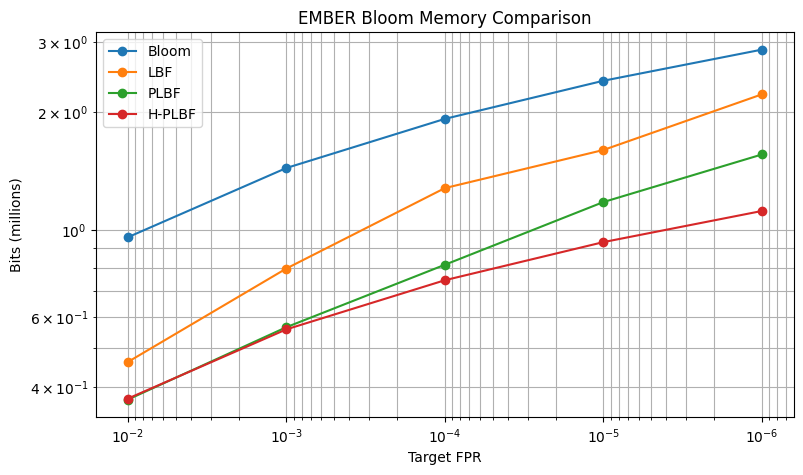

In [10]:
# %%
plt.figure(figsize=(9,5))

plt.loglog(results_df.TargetFPR, results_df.BloomBits/1e6, 'o-', label="Bloom")
plt.loglog(results_df.TargetFPR, results_df.LBF_bits/1e6, 'o-', label="LBF")
plt.loglog(results_df.TargetFPR, results_df.PLBF_bits/1e6, 'o-', label="PLBF")
plt.loglog(results_df.TargetFPR, results_df.HPLBF_bits/1e6, 'o-', label="H-PLBF")

plt.gca().invert_xaxis()
plt.xlabel("Target FPR")
plt.ylabel("Bits (millions)")
plt.title("EMBER Bloom Memory Comparison")

plt.legend()
plt.grid(True, which='both')

plt.savefig(os.path.join(OUT_DIR, "bf_only_memory.png"), dpi=300)
plt.show()
